In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [2]:
from google.colab import files
uploaded=files.upload()

Saving framingham.csv to framingham.csv


In [3]:
df = pd.read_csv("framingham.csv")

In [4]:
df = df.dropna()

In [5]:
X = df.drop("TenYearCHD", axis=1)
y = df["TenYearCHD"]

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [7]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

In [8]:
beta_0 = model.intercept_[0]
beta = model.coef_[0]

In [9]:
z = np.dot(X_test, beta) + beta_0
probabilities = 1 / (1 + np.exp(-z))

In [10]:
y_pred_formula = [1 if p >= 0.5 else 0 for p in probabilities]

In [11]:
accuracy = accuracy_score(y_test, y_pred_formula)
print("Accuracy (manual formula):", accuracy)

Accuracy (manual formula): 0.8346994535519126


In [12]:
print("Accuracy (model.score):", model.score(X_test, y_test))

Accuracy (model.score): 0.8346994535519126


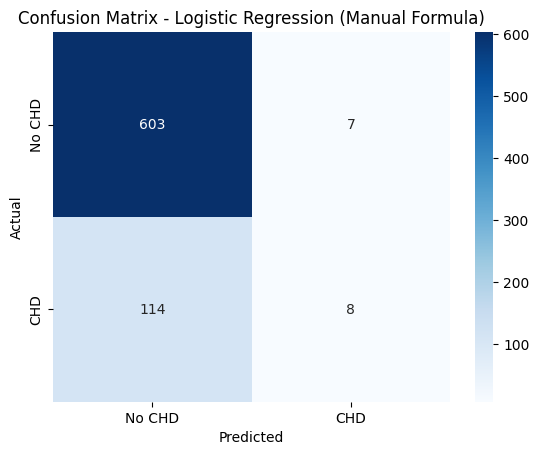

In [13]:
cm = confusion_matrix(y_test, y_pred_formula)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["No CHD", "CHD"], yticklabels=["No CHD", "CHD"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression (Manual Formula)")
plt.show()